# PhonePe Merchant Expansion Opportunity Analysis

**Portfolio level:** Data Analyst, 0–1 year experience  
**Decision:** Which districts should a merchant-growth team investigate first?  
**Stack:** Python, Pandas, MySQL 8, SQL, Power BI and DAX

This notebook explains the decision from the saved MySQL outputs. It is deliberately simple enough to discuss in a fresher interview while preserving real analytical controls: defined grain, reconciliation, time-aware comparisons, explicit eligibility rules, sensitivity analysis, and honest limitations.

## 1. Business framing

The project treats expansion as a **prioritisation problem**, not a prediction problem. A district becomes interesting when digital-payment demand is growing, activity per registered merchant is high, and the user base is large enough to justify field research. The output is an investigation queue; it is not proof of merchant shortage or expected ROI.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA = ROOT / 'data' / 'analysis'
FIGURES = ROOT / 'reports' / 'figures'

periods = pd.read_csv(DATA / 'dim_period.csv')
national = pd.read_csv(DATA / 'national_metrics.csv').sort_values('period_id')
states = pd.read_csv(DATA / 'state_metrics.csv')
opportunities = pd.read_csv(DATA / 'district_opportunities.csv')
shortlist = pd.read_csv(DATA / 'investigation_shortlist.csv').sort_values('investigation_rank')
validation = json.loads((DATA / 'validation.json').read_text())
print(f"Coverage: {periods.period_label.iloc[0]} to {periods.period_label.iloc[-1]}")
print(f"Eligible districts: {len(opportunities):,}; positive-momentum shortlist: {len(shortlist):,}")

Coverage: 2018-Q1 to 2026-Q2
Eligible districts: 680; positive-momentum shortlist: 624


## 2. Data trust checks

The raw public JSON was flattened to one row per state-quarter and district-quarter. Transaction counts, values, users, and merchants were checked for duplicate keys, missingness, negative values, and geographic reconciliation. Historical merchant values missing from the source remain null; they are not filled with zero.

In [2]:
checks = pd.Series(validation, name='passed').rename_axis('check').reset_index()
display(checks)
assert checks['passed'].all()

,check,passed
0,unique_district_quarter,True
1,latest_core_fields_complete,True
2,row_count_preserved_by_sql_joins,True
3,transaction_qoq_matches_pandas,True
4,users_per_merchant_matches_pandas,True
5,yoy_matches_same_quarter_last_year,True
6,score_matches_independent_pandas,True
7,state_transaction_contribution_sums_to_one,True
8,district_contribution_sums_to_one_within_state,True
9,score_in_range_0_to_100,True


## 3. National payment context

The latest quarter establishes the size and direction of activity. Registered users and merchants are cumulative ecosystem registrations, so they describe mapped reach rather than active monthly participants.

In [3]:
latest = national.iloc[-1]
summary = pd.DataFrame({
    'Metric': ['Transactions', 'Transaction value', 'Registered users', 'Registered merchants', 'QoQ transaction growth'],
    'Q2 2026': [f"{latest.transactions/1e9:,.2f}B", f"₹{latest.value_inr/1e12:,.2f}T",
                f"{latest.registered_users/1e6:,.2f}M", f"{latest.registered_merchants/1e6:,.2f}M",
                f"{latest.transaction_qoq:.2%}"]
})
display(summary)

,Metric,Q2 2026
0,Transactions,38.66B
1,Transaction value,₹45.50T
2,Registered users,711.65M
3,Registered merchants,50.71M
4,QoQ transaction growth,6.66%


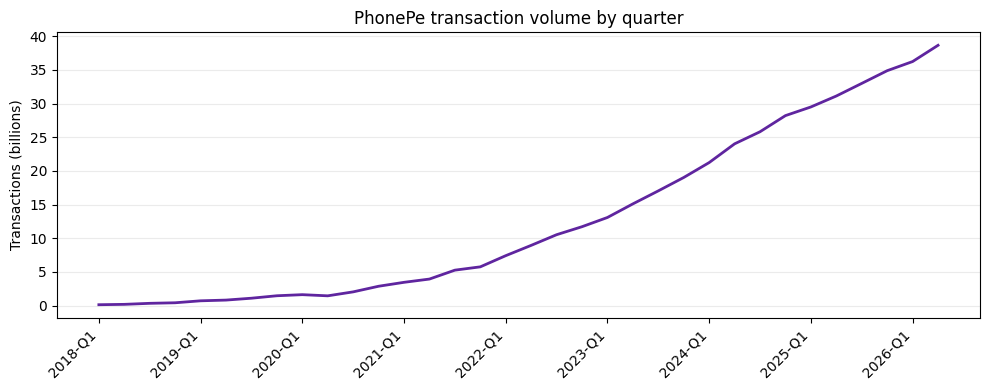

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(national['period_label'], national['transactions']/1e9, color='#5F259F', linewidth=2)
ax.set(title='PhonePe transaction volume by quarter', ylabel='Transactions (billions)', xlabel='')
ax.set_xticks(range(0, len(national), 4), national['period_label'].iloc[::4], rotation=45, ha='right')
ax.grid(axis='y', alpha=.25)
plt.tight_layout(); plt.show()

## 4. Opportunity score

Comparable districts must have at least 100,000 users, 1,000 merchants, one million quarterly transactions, and enough history for QoQ and same-quarter YoY comparisons. The score combines percentile ranks:

- 30% YoY transaction growth
- 25% transactions per merchant
- 25% users per merchant
- 20% registered user base

The shortlist also requires positive QoQ and YoY transaction growth and non-declining user and merchant counts. Percentiles reduce domination by large outliers and keep the score easy to explain.

In [5]:
cols = ['investigation_rank','district','state','opportunity_score','transaction_yoy',
        'transaction_qoq','users_per_merchant','registered_merchants']
top10 = shortlist.head(10)[cols].copy()
top10['transaction_yoy'] = top10['transaction_yoy'].map(lambda x: f'{x:.1%}')
top10['transaction_qoq'] = top10['transaction_qoq'].map(lambda x: f'{x:.1%}')
top10['opportunity_score'] = top10['opportunity_score'].round(1)
top10['users_per_merchant'] = top10['users_per_merchant'].round(1)
display(top10)

,investigation_rank,district,state,opportunity_score,transaction_yoy,transaction_qoq,users_per_merchant,registered_merchants
0,1,west godavari,andhra pradesh,86.7,30.5%,7.4%,24.6,48583
1,2,sangareddy,telangana,86.3,32.3%,7.9%,18.0,102640
2,3,dr br ambedkar konaseema,andhra pradesh,85.0,33.0%,7.8%,20.4,45653
3,4,east godavari,andhra pradesh,84.5,32.2%,8.5%,18.3,74989
4,5,sri potti sriramulu nellore,andhra pradesh,84.1,30.5%,9.6%,18.5,93583
5,6,alluri sitharama raju,andhra pradesh,83.6,37.9%,6.7%,36.6,11247
6,7,tirupati,andhra pradesh,82.3,28.2%,6.6%,18.7,118910
7,8,eluru,andhra pradesh,81.4,29.2%,9.0%,18.9,67639
8,9,mandya,karnataka,81.1,28.2%,10.5%,23.8,41069
9,10,hassan,karnataka,80.3,26.4%,8.5%,26.2,42357


## 5. Robustness and decision

A ranking can look precise even when its assumptions are uncertain. The project therefore compares equal weights, a version without transaction intensity, and a version without the size cutoffs. Nine of the default top ten remain under equal weights, while six remain when intensity is removed and six remain when cutoffs are removed. The six districts that also survive the no-intensity top ten form the stronger first field-research group.

In [6]:
sensitivity = pd.read_csv(DATA / 'score_sensitivity.csv')
display(sensitivity[['scenario','top10_overlap_with_base']])
stronger = shortlist.head(10).query('no_intensity_rank <= 10').sort_values('investigation_rank')
display(stronger[['district','state','opportunity_score','no_intensity_rank']])

,scenario,top10_overlap_with_base
0,opportunity_score,10
1,equal_weight_score,9
2,no_intensity_score,6


,district,state,opportunity_score,no_intensity_rank
0,west godavari,andhra pradesh,86.678940,2
1,sangareddy,telangana,86.273932,4
2,dr br ambedkar konaseema,andhra pradesh,84.992636,6
3,east godavari,andhra pradesh,84.491900,7
4,sri potti sriramulu nellore,andhra pradesh,84.116348,9
5,alluri sitharama raju,andhra pradesh,83.645066,8


## 6. Recommendation

Begin field validation with **West Godavari and Sangareddy**, followed by **Dr BR Ambedkar Konaseema, East Godavari, Sri Potti Sriramulu Nellore, and Alluri Sitharama Raju**. Validate active acceptance, merchant category gaps, competitor coverage, acquisition cost, and travel feasibility before spending. Measure 30-day active merchants and incremental transactions against comparable areas instead of counting sign-ups alone.

The result is intentionally cautious. PhonePe Pulse represents the PhonePe ecosystem, registrations are not activity, district totals combine categories, and the public data contains no shop universe, population denominator, competitor coverage, cost, revenue, or realized pilot outcome.

## 7. Portfolio discussion prompts

1. **Why MySQL?** It demonstrates data modelling, joins, window functions, reusable views, and reproducible business queries.
2. **Why same-quarter YoY?** It compares like seasons and avoids treating Q2 as if it followed Q2 of the prior year directly.
3. **Why no imputation for historical merchants?** Zero would mean no merchants, which the source does not establish.
4. **Why no machine learning?** The business needs an explainable research queue; there is no labelled outcome such as campaign conversion or incremental profit.
5. **What would improve the decision?** Active merchant counts, category-level district demand, merchant universe, population, competitive acceptance, acquisition cost, and pilot results.